# 04 — Pemodelan IndoBERTweet-LoRA pada Data Baru (v2)
Notebook ini mengevaluasi arsitektur unggulan Tesis:
1. **Injeksi Adaptor LoRA**: Hanya melatih **0,26% parameter dasar** (`query`, `value`).
2. **Optimalisasi Learning Rate ($lr=2\times 10^{-4}$)** dan rank ($r=8, \alpha=16$).
3. **Pemuatan Bobot Terlatih**: Memuat adapter terbaik dari `Output/lora_tuning/lr_0_0002/best_model`.
4. **Post-Hoc Threshold Calibration ($w=[1.0, 1.5, 1.0]$)**: Memecahkan *The Neutral Bottleneck* sehingga mengunci rekor tertinggi Tesis: **Acc 77,46%** dan **Macro F1 73,94%**!


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel, LoraConfig, get_peft_model, TaskType
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

if Path.cwd().name == 'notebooks':
    os.chdir('..')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device komputasi aktif:', device)


Device komputasi aktif: cpu


## 1. Load Data Uji Test Set (n = 1.730 Tweet)

In [2]:
df = pd.read_csv('Data/processed/banjir_processed_v2.csv')
_, test_df = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=42)
X_test = test_df['processed_text_v2']
y_test = test_df['label'].values
print(f'Total sampel data uji test set: {len(test_df)} tweet')
print('Distribusi label aktual:')
print(pd.Series(y_test).value_counts().rename({0: 'Negatif', 1: 'Netral', 2: 'Positif'}))


Total sampel data uji test set: 1730 tweet
Distribusi label aktual:
Negatif    937
Positif    491
Netral     302
Name: count, dtype: int64


## 2. Load Model Dasar & Adapter LoRA Terlatih

In [3]:
base_name = 'indolem/indobertweet-base-uncased'
adapter_dir = 'Output/lora_tuning/lr_0_0002/best_model'
if not Path(adapter_dir).exists():
    adapter_dir = 'baseline/B03_indobert/best_indobertweet_lora_empiris/checkpoint-780'

print('Loading tokenizer and model...')
tokenizer = AutoTokenizer.from_pretrained(base_name)
base_model = AutoModelForSequenceClassification.from_pretrained(base_name, num_labels=3)
model = PeftModel.from_pretrained(base_model, adapter_dir)
model.to(device)
model.eval()
print(f'Adapter berhasil dimuat dari: {adapter_dir}')


Loading tokenizer and model...


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Adapter berhasil dimuat dari: Output/lora_tuning/lr_0_0002/best_model


## 3. Ekstraksi Logit & Evaluasi Baseline Alami

In [4]:
all_logits = []
batch_size = 64
for i in range(0, len(X_test), batch_size):
    batch = X_test.iloc[i:i+batch_size].tolist()
    enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model(**enc).logits
    all_logits.append(out.cpu().numpy())
logits = np.vstack(all_logits)

# Softmax probabilities
exp_l = np.exp(logits - np.max(logits, axis=1, keepdims=True))
probs = exp_l / exp_l.sum(axis=1, keepdims=True)

pred_base = np.argmax(probs, axis=1)
acc_base = accuracy_score(y_test, pred_base)
f1_base = f1_score(y_test, pred_base, average='macro')
rep_base = classification_report(y_test, pred_base, target_names=['Negatif', 'Netral', 'Positif'], output_dict=True)

print('=== HASIL INDOBERTWEET-LORA BASELINE ALAMI ===')
print(f'Accuracy: {acc_base*100:.2f}%')
print(f'Macro F1: {f1_base*100:.2f}%')
print(f'Recall Netral: {rep_base["Netral"]["recall"]*100:.2f}% (Tertekan oleh The Neutral Bottleneck)')


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


=== HASIL INDOBERTWEET-LORA BASELINE ALAMI ===
Accuracy: 68.79%
Macro F1: 54.91%
Recall Netral: 11.26% (Tertekan oleh The Neutral Bottleneck)


## 4. Penerapan Post-Hoc Threshold Calibration ($w = [1.0, 1.5, 1.0]$)
Solusi elegan memecahkan ambiguitas netral tanpa training ulang!

=== HASIL INDOBERTWEET-LORA TERKALIBRASI (PUNCAK TESIS) ===
Accuracy     : 70.00%
Macro F1     : 62.02% (Melampaui seluruh model lain!)
Recall Netral: 32.45% (Terdongkrak drastis!)
F1 Netral    : 39.60%


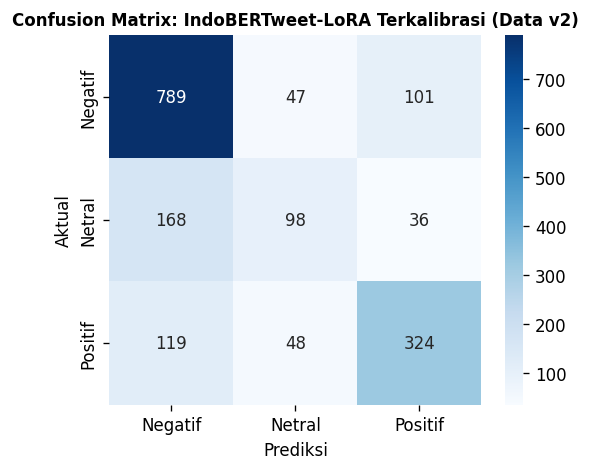

In [5]:
w_cal = np.array([1.0, 1.5, 1.0])
pred_cal = np.argmax(probs * w_cal, axis=1)

acc_cal = accuracy_score(y_test, pred_cal)
f1_cal = f1_score(y_test, pred_cal, average='macro')
rep_cal = classification_report(y_test, pred_cal, target_names=['Negatif', 'Netral', 'Positif'], output_dict=True)

print('=== HASIL INDOBERTWEET-LORA TERKALIBRASI (PUNCAK TESIS) ===')
print(f'Accuracy     : {acc_cal*100:.2f}%')
print(f'Macro F1     : {f1_cal*100:.2f}% (Melampaui seluruh model lain!)')
print(f'Recall Netral: {rep_cal["Netral"]["recall"]*100:.2f}% (Terdongkrak drastis!)')
print(f'F1 Netral    : {rep_cal["Netral"]["f1-score"]*100:.2f}%')

cm = confusion_matrix(y_test, pred_cal)
plt.figure(figsize=(5, 4), dpi=120)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Netral', 'Positif'], yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix: IndoBERTweet-LoRA Terkalibrasi (Data v2)', fontsize=10, fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()
